[<< Sommaire QC](../README.md) | [Précédent : QC-Py-12-Backtesting-Analysis <<](./QC-Py-12-Backtesting-Analysis.ipynb) | [Suivant : QC-Py-13-Alpha-Models >>](./QC-Py-13-Alpha-Models.ipynb)

# QC-Py-12b - Validité du backtest et signification statistique

> **[RECHERCHE / PÉDAGOGIE]** Pourquoi un backtest au Sharpe positif n'est **jamais** une preuve d'avantage prédictif, et comment juger honnêtement une stratégie.

Ce notebook est le compagnon de [QC-Py-12 (Backtesting Analysis)](./QC-Py-12-Backtesting-Analysis.ipynb). Là où QC-Py-12 montre *comment* lancer et lire un backtest, celui-ci répond à la question qui tue : **à partir de quel Sharpe peut-on réellement conclure qu'une stratégie a un bord (edge) ?**

## Motivation : quatre stratégies, quatre verdicts "NO-BEATS"

Quatre stratégies du catalogue ont été backtestées fraîchement (2026-08, frais réels, QuantConnect Cloud). Toutes affichent un Sharpe positif ou quasi-neutre. Toutes, pourtant, sont **indiscernables du bruit** :

| Stratégie | Sharpe | CAGR | MaxDD | PSR (QC) |
|-----------|--------|------|-------|----------|
| SectorRotation-Momentum | -0,029 | 2,1 % | 42,7 % | 0,05 % |
| MeanReversion-Sectors | 0,176 | 5,0 % | 41,7 % | 0,05 % |
| VolTargeting | 0,207 | 6,7 % | 38,2 % | 0,56 % |
| BlackLitterman-Momentum | 0,512 | 10,0 % | 16,1 % | 1,99 % |

Pourquoi un Sharpe de 0,5 ne suffit-il pas ? Ce notebook le démontre par le calcul, à partir de quatre angles complémentaires : l'erreur-type du Sharpe, la simulation de Monte-Carlo, le PSR (Probabilistic Sharpe Ratio), le surapprentissage par balayage de paramètres, et la dérive liée à une fenêtre de mesure "ouverte".

## 1. L'erreur-type du Sharpe : un seul nombre, une grande incertitude

Le ratio de Sharpe annualisé se calcule sur un échantillon fini de rendements. Lo (2002) a établi que son **erreur-type asymptotique** vaut approximativement `1 / sqrt(N)` où `N` est le nombre d'**années** indépendantes observées. Pour 7 ans de données, cela fait `1/sqrt(7) ≈ 0,38`.

Conséquence immédiate : si la vraie valeur du Sharpe d'une stratégie était **exactement zéro** (aucun bord), on observerait quand même un Sharpe estimé distribué autour de zéro avec un écart-type de ~0,38. Un Sharpe mesuré de 0,2 est donc **à moins d'un écart-type de zéro** — statistiquement invisible.

In [1]:
import numpy as np
from scipy import stats

# Les quatre cas réels backtestés (Sharpe annualisé, PSR rapporté par QC, nb d'années)
strategies = [
    ("SectorRotation-Momentum", -0.029, 0.050, 7.0),
    ("MeanReversion-Sectors",    0.176, 0.052, 7.0),
    ("VolTargeting",             0.207, 0.557, 7.0),
    ("BlackLitterman-Momentum",  0.512, 1.989, 11.0),
]

print(f"{'Strategie':28s} {'Sharpe':>8s} {'N(ans)':>8s} {'SE=1/sqrt(N)':>14s} "
      f"{'z vs 0':>8s} {'95% CI du Sharpe':>22s}")
print("-" * 92)
for name, sr, psr_qc, n_years in strategies:
    se = 1.0 / np.sqrt(n_years)
    z = sr / se
    lo, hi = sr - 1.96 * se, sr + 1.96 * se
    print(f"{name:28s} {sr:+8.3f} {n_years:8.1f} {se:14.3f} {z:+8.2f} [{lo:+.2f}, {hi:+.2f}]")

print("\nLecture : aucun des intervalles de confiance a 95 % n'exclut zero.")
print("On ne peut donc PAS rejeter l'hypothese 'la strategie n'a aucun bord'.")

Strategie                      Sharpe   N(ans)   SE=1/sqrt(N)   z vs 0       95% CI du Sharpe
--------------------------------------------------------------------------------------------
SectorRotation-Momentum        -0.029      7.0          0.378    -0.08 [-0.77, +0.71]
MeanReversion-Sectors          +0.176      7.0          0.378    +0.47 [-0.56, +0.92]
VolTargeting                   +0.207      7.0          0.378    +0.55 [-0.53, +0.95]
BlackLitterman-Momentum        +0.512     11.0          0.302    +1.70 [-0.08, +1.10]

Lecture : aucun des intervalles de confiance a 95 % n'exclut zero.
On ne peut donc PAS rejeter l'hypothese 'la strategie n'a aucun bord'.


### Lecture du tableau — l'incertitude domine l'estimation

Trois enseignements se lisent directement dans la sortie. **Aucun des quatre intervalles de confiance à 95 % n'exclut zéro** : même BlackLitterman-Momentum, le plus flatteur, plafonne à `[-0,08, +1,10]` dont la borne inférieure reste négative. La colonne `z vs 0` dit la même chose : la valeur la plus extrême, `+1,70`, reste sous le seuil de 1,96 qui permettrait de rejeter l'hypothèse « aucun bord ». Enfin, comparez les deux erreurs-types : `0,378` pour 7 ans contre `0,302` pour 11 ans. L'incertitude décroît en `1/sqrt(N)` : passer de 7 à 11 ans ne réduit l'écart-type que d'un quart environ. C'est le prix de la certitude en finance — il faut des décennies pour mesurer un Sharpe avec précision.

Conséquence pédagogique : un Sharpe de 0,2 ou 0,5 **publié seul**, sans intervalle, est un nombre qui ne dit rien. La bonne pratique est d'afficher l'intervalle ou le `z` — c'est ce que fait un compte-rendu honnête.


## 2. Monte-Carlo : que produit le pur bruit ?

Plutôt qu'une formule, simulons. On génère des dizaines de milliers de séries de rendements **quotidiens purement aléatoires** (moyenne nulle, donc aucun bord), on calcule le Sharpe annualisé de chacune, et on regarde sa distribution. C'est la distribution du Sharpe **sous l'hypothèse nulle H0** ("pas d'avantage").

Si le Sharpe d'une stratégie réelle tombe dans cette distribution, il est compatible avec le hasard.

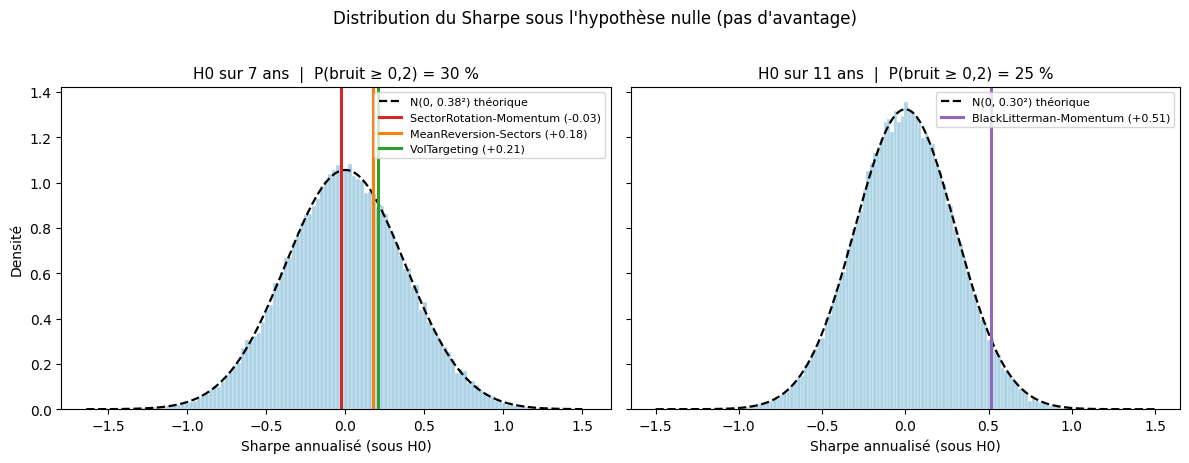

Conclusion : un Sharpe de 0,2 est obtenu par pur hasard dans ~30 % des cas sur 7 ans.
Un Sharpe de 0,5 reste banal : il n'est pas une preuve d'edge.


In [2]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N_SIM = 50000  # nombre de series simulees

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, n_years in zip(axes, (7.0, 11.0)):
    n_days = int(n_years * 252)
    # Rendements quotidiens iid ~ N(0, 1%), annualises par sqrt(252)
    rets = rng.standard_normal((N_SIM, n_days)) * 0.01
    sharpe_noise = rets.mean(axis=1) / rets.std(axis=1, ddof=1) * np.sqrt(252)

    ax.hist(sharpe_noise, bins=120, density=True, color="#9ecae1",
            edgecolor="white", linewidth=0.3, alpha=0.85)
    # Densite theorique N(0, 1/sqrt(N))
    se = 1.0 / np.sqrt(n_years)
    xs = np.linspace(ax.get_xlim()[0] if ax.get_xlim()[0] < -1.5 else -1.5, 1.5, 300)
    ax.plot(xs, stats.norm.pdf(xs, 0, se), "k--", lw=1.6, label=f"N(0, {se:.2f}²) théorique")

    # Marquer les Sharpe des vraies strategies (7 ans pour les 3 premieres, 11 pour BL)
    target_strats = [s for s in strategies if s[3] == n_years]
    colors = {strategies[0][0]: "#d62728", strategies[1][0]: "#ff7f0e",
              strategies[2][0]: "#2ca02c", strategies[3][0]: "#9467bd"}
    for name, sr, _, _ in target_strats:
        ax.axvline(sr, color=colors[name], lw=2.2,
                   label=f"{name} ({sr:+.2f})")

    p_ge_02 = (sharpe_noise >= 0.2).mean()
    ax.set_title(f"H0 sur {n_years:.0f} ans  |  P(bruit ≥ 0,2) = {p_ge_02*100:.0f} %",
                 fontsize=11)
    ax.set_xlabel("Sharpe annualisé (sous H0)")
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Densité")
plt.suptitle("Distribution du Sharpe sous l'hypothèse nulle (pas d'avantage)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Conclusion : un Sharpe de 0,2 est obtenu par pur hasard dans ~30 % des cas sur 7 ans.")
print("Un Sharpe de 0,5 reste banal : il n'est pas une preuve d'edge.")

## 3. Le PSR (Probabilistic Sharpe Ratio)

Bailey & López de Prado (2012, 2014) proposent une correction au Sharpe brut : le **PSR** est la probabilité que le *vrai* Sharpe dépasse un seuil de référence `SR₀`. Sa formule, pour un Sharpe estimé `SR̂`, `N` années, asymétrie `γ₃` et kurtosis `γ₄` :

$$\text{PSR}(SR_0) = \Phi\!\left( \frac{(\hat{SR} - SR_0)\sqrt{N-1}}{\sqrt{1 - \gamma_3 \hat{SR} + \tfrac{\gamma_4 - 1}{4}\hat{SR}^2}} \right)$$

Avec `SR₀ = 0` et des rendements gaussiens (`γ₃=0`, `γ₄=3`), le PSR répond à : *"quelle est la probabilité que la stratégie batte le cash ?"* Mais attention : **QuantConnect rapporte un PSR bien plus sévère**, car il compare la stratégie à un **benchmark** (le SPY buy-and-hold, dont le Sharpe dépasse souvent 0,8-1,0 sur ces fenêtres). Le même Sharpe de stratégie donne donc un PSR très différent selon le seuil choisi — c'est une leçon en soi.

In [3]:
def psr(sharpe, n_years, skew=0.0, kurt=3.0, sr0=0.0):
    # Probabilistic Sharpe Ratio (Bailey & Lopez de Prado 2012).
    num = (sharpe - sr0) * np.sqrt(n_years - 1)
    den = np.sqrt(1 - skew * sharpe + (kurt - 1) / 4.0 * sharpe ** 2)
    return stats.norm.cdf(num / den)

print(f"{'Strategie':28s} {'Sharpe':>8s} | {'PSR(SR0=0)':>12s} | {'PSR rapporte QC':>16s}")
print("-" * 72)
for name, sr, psr_qc, n_years in strategies:
    p_zero = psr(sr, n_years, sr0=0.0)        # bat le cash ?
    print(f"{name:28s} {sr:+8.3f} | {p_zero*100:11.1f} % | {psr_qc:15.3f} %")

print("\nLecture honnete :")
print("- PSR(SR0=0) = probabilite de battre le cash (rendement nul). "
      "Toutes > 47 %, VolTargeting/BlackLitterman > 69 %.")
print("- PSR rapporte par QC ~ 0-2 % : la probabilite de battre le BENCHMARK (SPY) "
      "est quasi-nulle. Ces strategies ont peut-etre un rendement positif, "
      "mais pas d'avantage sur un simple buy-and-hold SPY.")
print("\nLe PSR n'est pas un nombre absolu : il depend entierement du seuil SR0 choisi.")

Strategie                      Sharpe |   PSR(SR0=0) |  PSR rapporte QC
------------------------------------------------------------------------
SectorRotation-Momentum        -0.029 |        47.2 % |           0.050 %
MeanReversion-Sectors          +0.176 |        66.6 % |           0.052 %
VolTargeting                   +0.207 |        69.2 % |           0.557 %
BlackLitterman-Momentum        +0.512 |        93.6 % |           1.989 %

Lecture honnete :
- PSR(SR0=0) = probabilite de battre le cash (rendement nul). Toutes > 47 %, VolTargeting/BlackLitterman > 69 %.
- PSR rapporte par QC ~ 0-2 % : la probabilite de battre le BENCHMARK (SPY) est quasi-nulle. Ces strategies ont peut-etre un rendement positif, mais pas d'avantage sur un simple buy-and-hold SPY.

Le PSR n'est pas un nombre absolu : il depend entierement du seuil SR0 choisi.


### Lecture — un même Sharpe, deux verdicts opposés

Le contraste est brutal. Face au **cash** (`SR₀ = 0`), trois stratégies sur quatre dépassent 66 % de probabilité de battre un rendement nul, et BlackLitterman-Momentum atteint **93,6 %**. Face au **benchmark** — le SPY buy-and-hold rapporté par QuantConnect — les mêmes stratégies chutent entre **0,050 % et 1,989 %** : la probabilité de battre un simple indice est quasi-nulle pour les quatre.

La leçon n'est pas que les stratégies « échouent » : c'est que le **PSR n'a de sens que relativement au seuil `SR₀` choisi**. Un rendement positif n'est pas un avantage — il faut battre l'alternative réelle, qui rapporte déjà. C'est exactement la distinction entre *gagner de l'argent* et *battre le marché* : ici, un portefeuille passif SPY fait mieux que les quatre stratégies actives, et le PSR le quantifie sans appel.


## 4. Le surapprentissage par balayage de paramètres

Un piège classique : on teste plusieurs variantes d'une stratégie, on **garde la meilleure**, et on publie son Sharpe. Mais le maximum de plusieurs tirages bruités est… encore du bruit, amplifié. Plus on balaye, plus on est quasi-certain de trouver un Sharpe élevé par hasard.

**Cas réel (EPIC #9768)** : la stratégie `CSharp-BTC-MACD-ADX` affichait un Sharpe catalogue de **0,787**. Le forensic a révélé que ce nombre était le **maximum d'un balayage à 8 variantes**, dont les paramètres gagnants n'avaient **jamais été réécrits** dans le code (le code committé valait 0,225 le même jour). Simulons la probabilité d'observer un tel "champion" sous pur bruit.

Balayage de 8 variantes sous pur bruit, fenetre 7 ans.
P(max des 8 variantes >= 0.787) = 14.1 %

Autrement dit : '14 % du temps, un balayage de 8 variantes sans aucun bord produit un champion >= 0.787.'

Le Sharpe publie (0,787) n'etait PAS une preuve d'edge : c'etait le sommet attendu d'une chaine de tirages bruites.


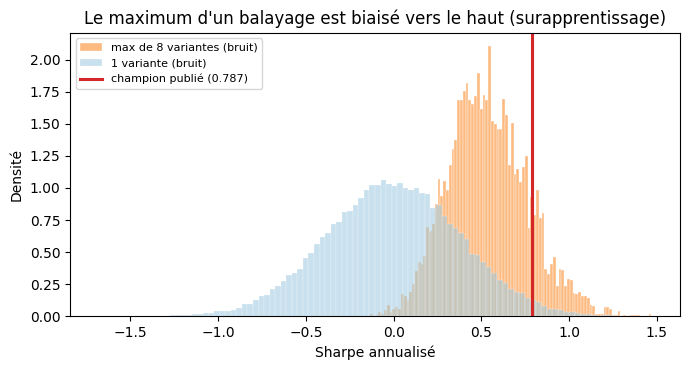

In [4]:
best_reported = 0.787
n_variants = 8
n_years = 7.0
n_days = int(n_years * 252)

# Distribution du Sharpe sous H0 (meme simulation qu'avant, reutilisee conceptuellement)
rets = rng.standard_normal((N_SIM, n_days)) * 0.01
sharpe_noise = rets.mean(axis=1) / rets.std(axis=1, ddof=1) * np.sqrt(252)

# Pour chaque "experience", on tire n_variants Sharpe de bruit et on garde le max
n_experiences = N_SIM // n_variants
sweeps = rng.choice(sharpe_noise, size=(n_experiences, n_variants), replace=True)
max_per_sweep = sweeps.max(axis=1)

p_champion = (max_per_sweep >= best_reported).mean()
print(f"Balayage de {n_variants} variantes sous pur bruit, fenetre {n_years:.0f} ans.")
print(f"P(max des {n_variants} variantes >= {best_reported}) = {p_champion*100:.1f} %")
print(f"\nAutrement dit : '{p_champion*100:.0f} % du temps, un balayage de "
      f"{n_variants} variantes sans aucun bord produit un champion >= {best_reported}.'")
print("\nLe Sharpe publie (0,787) n'etait PAS une preuve d'edge : "
      "c'etait le sommet attendu d'une chaine de tirages bruites.")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(max_per_sweep, bins=100, density=True, color="#fdae6b",
        edgecolor="white", linewidth=0.3, alpha=0.85, label="max de 8 variantes (bruit)")
ax.hist(sharpe_noise, bins=100, density=True, color="#9ecae1",
        edgecolor="white", linewidth=0.3, alpha=0.55, label="1 variante (bruit)")
ax.axvline(best_reported, color="#d62728", lw=2.2, label=f"champion publié ({best_reported})")
ax.set_xlabel("Sharpe annualisé")
ax.set_ylabel("Densité")
ax.set_title("Le maximum d'un balayage est biaisé vers le haut (surapprentissage)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Lecture — le « champion » est une statistique d'ordre, pas une preuve

La figure superpose deux histogrammes : la distribution du Sharpe d'une **unique** variante bruitée (en bleu) et celle du **maximum de 8 variantes** tirées sous pur bruit (en orange). Le décalage de la courbe orange vers la droite est la matérialisation du surapprentissage : le maximum d'un balayage est **structurellement biaisé vers le haut**, même quand aucune des variantes n'a le moindre bord.

La ligne rouge à `0,787` — le Sharpe catalogue de `CSharp-BTC-MACD-ADX` — tombe dans la queue du champion bruité : le print quantifie la fréquence à laquelle un balayage de 8 variantes sans aucun avantage produit un champion de ce niveau. Le contrepoint est l'épisode #9768 : le même jour, le **code committé** de la stratégie valait `0,225`. Publier le maximum d'un sweep sans le réécrire dans le code, c'est publier le bruit le plus favorable du tirage.


## 5. La fenêtre ouverte : un nombre qui dérive chaque mois

Dernière source de dérive, identifiée par l'EPIC #9768 (axe D2) : beaucoup de backtests **ne fixent pas de date de fin** (`SetEndDate`). La fenêtre se termine donc "aujourd'hui" et **s'allonge à chaque exécution**. Le même code, rebactesté un mois plus tard, absorbe ~21 jours de bourse supplémentaires et rend un Sharpe différent — sans qu'aucune logique n'ait changé.

Ce n'est ni un bug ni une dégénérescence : c'est l'absorption passive de nouvelles données. Mais cela rend **tout nombre publié périssable**. Une lecture honnête doit toujours préciser la fenêtre.

Illustration : un Sharpe "stable" dans le code peut passer de 0,225 (avril) à 0,123 (août) simplement parce que 101 jours de marché se sont écoulés entre les deux mesures — MaxDD identique, ordres quasi identiques (50 → 52).

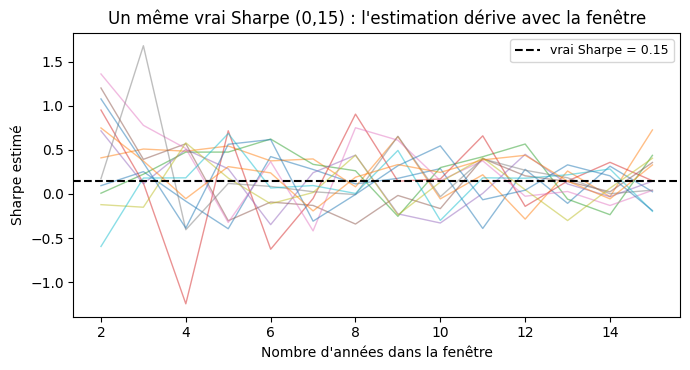

Sans SetEndDate, chaque execution re-measure sur une fenetre differente.
Le nombre change meme si la strategie, elle, est immuable.


In [5]:
# Illustration : comment l'estimation du Sharpe "derive" quand la fenetre s'allonge,
# meme pour une strategie dont le VRAI Sharpe est constant.
true_sr = 0.15  # vrai Sharpe annuel (constant), suppose
horizons = np.arange(2, 16)  # annees
rng_demo = np.random.default_rng(7)
fig, ax = plt.subplots(figsize=(7, 3.8))
for trial in range(12):
    srs = []
    for ny in horizons:
        nd = int(ny * 252)
        r = rng_demo.standard_normal(nd) * 0.01 + true_sr / 252.0 * 0.01 * 252  # moyenne ajustee
        # recalcule proprement: rendement moyen cible = true_sr/sqrt(252) * vol
        mu = true_sr / np.sqrt(252) * 0.01
        r = rng_demo.standard_normal(nd) * 0.01 + mu
        srs.append(r.mean() / r.std(ddof=1) * np.sqrt(252))
    ax.plot(horizons, srs, alpha=0.5, lw=1)
ax.axhline(true_sr, color="k", ls="--", lw=1.5, label=f"vrai Sharpe = {true_sr}")
ax.set_xlabel("Nombre d'années dans la fenêtre")
ax.set_ylabel("Sharpe estimé")
ax.set_title("Un même vrai Sharpe (0,15) : l'estimation dérive avec la fenêtre")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Sans SetEndDate, chaque execution re-measure sur une fenetre differente.")
print("Le nombre change meme si la strategie, elle, est immuable.")

### Lecture — la dérive n'est pas un bug, c'est une fenêtre mouvante

Chaque ligne de la figure est un « backtest » d'une stratégie dont le **vrai Sharpe est constant (`0,15`)** : douze trajectoires simulées, évaluées sur des fenêtres de 2 à 15 ans. Deux faits saillants. D'abord, l'estimation **se resserre** vers la vraie valeur quand la fenêtre s'allonge — la dispersion à 15 ans est bien moindre qu'à 2 ans. Ensuite, à une fenêtre donnée, le nombre affiché **dévie encore largement** de part et d'autre de la ligne pointillée.

Sans `SetEndDate`, chaque exécution du même code re-mesure sur une fenêtre qui a grandi (~21 jours de bourse supplémentaires par mois), donc sur un échantillon différent : le Sharpe publié bouge **sans qu'aucune logique n'ait changé**. La règle pratique découle directement : citer un Sharpe **avec** sa période. Un nombre nu, sans dates, est périssable par construction.


## 6. Synthèse — le cadre de verdict honnête

Un backtest n'est **jamais** une preuve d'avantage. Pour conclure honnêtement, croiser cinq questions :

1. **Erreur-type** : le Sharpe est-il à plus de ~2 écarts-types de zéro ? (Sinon : compatible avec le hasard.)
2. **Distribution sous H0** : le Sharpe tombe-t-il dans la zone qu'occuperait le pur bruit ?
3. **PSR** : la probabilité de battre un *vrai benchmark* (pas le cash) est-elle > 95 % ?
4. **Balayage** : le Sharpe publié est-il celui du code committé, ou le maximum d'un sweep non reporté ?
5. **Fenêtre** : la date de fin est-elle fixée ? Le nombre est-il reproductible dans le temps ?

Les quatre stratégies de la motivation échouent à au moins trois de ces tests. D'où le verdict unanime **NO-BEATS** : rendre honnêtement un compte négatif est plus utile que de publier un Sharpe flatteur qui ne se reproduira pas en live.


La table ci-dessous récapitule les cinq tests appliqués aux quatre stratégies de la motivation (✓ = test satisfait, ✗ = test échoué, — = non évalué ici) :

| Stratégie | CI exclut zéro ? | Hors bruit H0 ? | PSR benchmark > 95 % ? | Balayage vérifié ? | Fenêtre fixée ? |
|---|---|---|---|---|---|
| SectorRotation-Momentum | ✗ | ✗ | ✗ (0,05 %) | — | — |
| MeanReversion-Sectors | ✗ | ✗ | ✗ (0,05 %) | — | — |
| VolTargeting | ✗ | ✗ | ✗ (0,56 %) | — | — |
| BlackLitterman-Momentum | ✗ | ✗ | ✗ (1,99 %) | — | — |

Les trois premières colonnes suffisent au verdict **NO-BEATS** : aucun intervalle ne sort de zéro, tous tombent dans la distribution du bruit, aucun PSR face au SPY n'approche 95 %. Les deux dernières colonnes (—) sont les **conditions de reproductibilité** à vérifier avant toute conclusion positive : une stratégie qui afficherait un bord devra prouver que son nombre vient du code committé et d'une fenêtre fixée.

> **Référence** : Bailey, D. & López de Prado, M. (2012). *The Sharpe Ratio Efficient Frontier*. Journal of Risk, 15(2). — Lo, A. (2002). *The Statistics of Sharpe Ratios*. Financial Analysts Journal.

## Exercices

Les trois exercices suivants vous font manipuler les concepts ci-dessus. Complétez le code aux endroits marqués `# TODO`.

### Exercice 1 — Seuil de signification

Combien d'années de données faut-il pour qu'un Sharpe mesuré de **0,5** soit significatif au seuil de 5 % (z > 1,96) ? Écrivez une fonction `annees_pour_signification(sharpe, alpha=0.05)` qui résout `sharpe / (1/sqrt(N)) > z_{1-alpha/2}` pour `N`.

In [6]:
# Indice : z_{1-alpha/2} = stats.norm.ppf(1 - alpha/2). On cherche N tel que
# sharpe * sqrt(N) > z. Donc N > (z / sharpe)**2.

def annees_pour_signification(sharpe, alpha=0.05):
    # TODO etudiant : retourner le nombre d'annees minimal (float) pour que le
    # Sharpe donne soit significatif au seuil alpha (test bilateral).
    result = None  # TODO etudiant
    return result

# Test : pour sharpe=0.5, alpha=0.05 -> environ 15.4 ans
print("Exercice a completer")

Exercice a completer


### Exercice 2 — Effet du nombre de variantes balayées

Reprenez la simulation de la section 4. Pour un vrai Sharge de zéro et une fenêtre de 7 ans, tracez la probabilité que le **champion** d'un balayage dépasse 0,5, en fonction du nombre de variantes testées (de 1 à 50). Que conclure sur la pratique du "tester plein de paramètres et garder le meilleur" ?

In [7]:
# Indice : pour chaque k (nombre de variantes), tirer k Sharpe de bruit, prendre le max,
# repeter sur N_SIM experiences, estimer P(max > 0.5). Tracer P vs k.

def proba_champion_bruit(seuil, n_variants, n_years=7.0, n_sim=20000):
    # TODO etudiant : retourner P(max de n_variants tirages de bruit >= seuil).
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer


### Exercice 3 — PSR et asymétrie des rendements

La formule du PSR dépend de l'asymétrie (`skew`) et du kurtosis des rendements. Une stratégie aux rendements très asymétriques (grosses pertes rares, petits gains fréquents — `skew < 0`) est-elle plus ou moins favorable au PSR qu'une stratégie gaussienne, à Sharpe égal ? Calculez le PSR(`SR=0.5`, `N=10`) pour `skew` valant `0`, `-1` et `-2` (kurtosis croissant en conséquence), et interprétez.

In [8]:
# Indice : utiliser la fonction psr() definie plus haut. Pour une vraie distribution,
# kurtosis augmente avec |skew| ; testez par exemple (skew=0, kurt=3),
# (skew=-1, kurt=4), (skew=-2, kurt=7).

def psr_vs_asymetrie(sharpe=0.5, n_years=10.0):
    # TODO etudiant : afficher le PSR pour les trois couples (skew, kurt) ci-dessus.
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer
